# Tyre Strategy & Degradation Analysis
How much slower do laps get as tyres age, how well can lap times be predicted from tyre age, compound and track temperature, and does pitting first (undercut) or later (overcut) pay off?

## 1. Setup

In [1]:
import os
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("../f1_cache")

## 2. Load one race
Using the 2025 Italian Grand Prix (Monza) to explore the data before the combined dataset was available.

In [2]:
session = fastf1.get_session(2025, "Monza", "R")
session.load(telemetry=False)
laps = session.laps
print(len(laps), "laps loaded")

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '44', '23', '5', '12', '6', '55', '87', '22', '30', '31', '10', '43', '18', '14', '27']


974 laps loaded


## 3. Explore the tyre columns
- `Compound`: SOFT, MEDIUM or HARD
- `TyreLife`: how many laps that set of tyres has done
- `Stint`: which stint the driver is on (1 = first set, 2 = after the first pit stop, ...)

In [3]:
laps[["Driver", "LapNumber", "LapTime", "Compound", "TyreLife", "Stint", "PitInTime", "TrackStatus"]].head(20)

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,PitInTime,TrackStatus
0,VER,1.0,0 days 00:01:27.159000,MEDIUM,1.0,1.0,NaT,1
1,VER,2.0,0 days 00:01:24.859000,MEDIUM,2.0,1.0,NaT,1
2,VER,3.0,0 days 00:01:23.512000,MEDIUM,3.0,1.0,NaT,1
3,VER,4.0,0 days 00:01:23.262000,MEDIUM,4.0,1.0,NaT,1
4,VER,5.0,0 days 00:01:23.588000,MEDIUM,5.0,1.0,NaT,1
5,VER,6.0,0 days 00:01:23.576000,MEDIUM,6.0,1.0,NaT,1
6,VER,7.0,0 days 00:01:23.310000,MEDIUM,7.0,1.0,NaT,1
7,VER,8.0,0 days 00:01:23.139000,MEDIUM,8.0,1.0,NaT,1
8,VER,9.0,0 days 00:01:23.101000,MEDIUM,9.0,1.0,NaT,1
9,VER,10.0,0 days 00:01:23.088000,MEDIUM,10.0,1.0,NaT,1


## 4. Clean the laps
Remove pit in/out laps, safety car and yellow flag laps, unusually slow laps, and laps with no time.

In [4]:
clean = laps.pick_wo_box()           # remove pit in/out laps
clean = clean.pick_track_status("1") # green flag only (no safety car)
clean = clean.pick_quicklaps()       # remove laps slower than 107% of the fastest
clean = clean[clean["LapTime"].notna()].copy()
clean["LapTimeSeconds"] = clean["LapTime"].dt.total_seconds()

print(len(laps), "->", len(clean), "laps after cleaning")

974 -> 894 laps after cleaning


## 5. Lap time vs tyre age
**Note:** cars also get faster during a race as fuel burns off, which works against tyre wear. Raw plots can therefore understate degradation. This is handled later by including `LapNumber` in the regression.

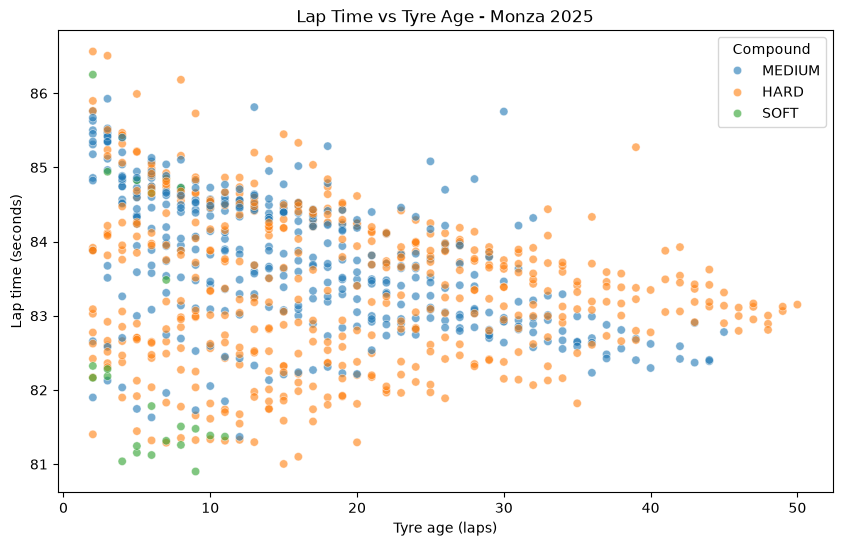

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean, x="TyreLife", y="LapTimeSeconds", hue="Compound", alpha=0.6)
plt.title("Lap Time vs Tyre Age - Monza 2025")
plt.xlabel("Tyre age (laps)")
plt.ylabel("Lap time (seconds)")
plt.show()

## 6. Combined dataset (5 races, 2025)
Loading the merged laps + weather data from the data pipeline.

In [6]:
df = pd.read_csv("../data/processed/cleaned_laps.csv")
print(df.shape)
print(df["Race"].value_counts())
df[["Race", "Driver", "LapNumber", "LapTime_s", "Compound", "TyreLife", "TrackTemp", "Rainfall"]].head()

(5305, 43)
Race
Monaco         1423
Bahrain        1115
Suzuka         1059
Monza           974
Silverstone     734
Name: count, dtype: int64


,Race,Driver,LapNumber,LapTime_s,Compound,TyreLife,TrackTemp,Rainfall
0,Bahrain,PIA,1.0,98.693,SOFT,4.0,31.9,False
1,Bahrain,RUS,1.0,99.582,SOFT,4.0,31.9,False
2,Bahrain,NOR,1.0,100.424,SOFT,4.0,31.9,False
3,Bahrain,LEC,1.0,101.332,MEDIUM,1.0,31.9,False
4,Bahrain,GAS,1.0,102.050,SOFT,4.0,31.9,False


In [7]:
clean = df[
    df["PitInTime"].isna()                                      # not a pit-in lap
    & df["PitOutTime"].isna()                                   # not a pit-out lap
    & (pd.to_numeric(df["TrackStatus"], errors="coerce") == 1)  # green flag only
    & (df["Deleted"] != True)                                   # not deleted for track limits
    & df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])           # dry tyres only
].copy()

# Remove unusually slow laps: over 107% of each race's fastest lap
fastest = clean.groupby("Race")["LapTime_s"].transform("min")
clean = clean[clean["LapTime_s"] <= fastest * 1.07]

print(len(df), "→", len(clean), "laps after cleaning")
clean.groupby(["Race", "Compound"]).size().unstack()

5305 → 3713 laps after cleaning


Compound,HARD,MEDIUM,SOFT
Race,,,
Bahrain,262,445,240
Monaco,468,285,29
Monza,465,387,24
Silverstone,8,85,24
Suzuka,516,417,58


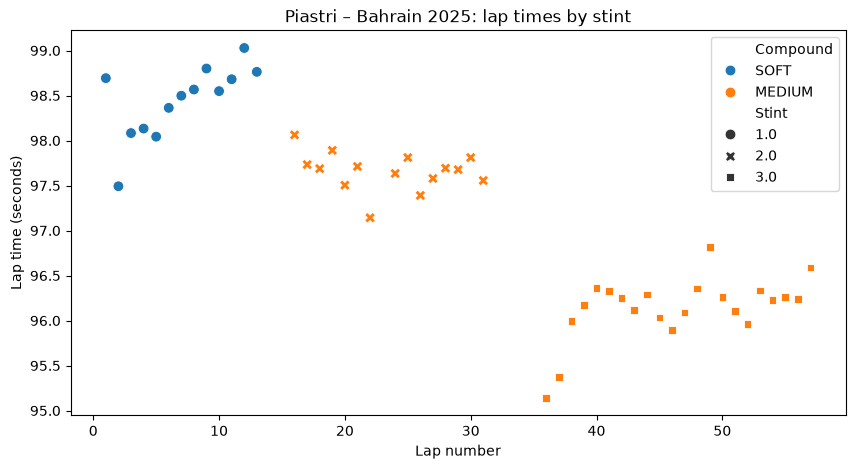

In [8]:
driver = clean[(clean["Race"] == "Bahrain") & (clean["Driver"] == "PIA")]

plt.figure(figsize=(10, 5))
sns.scatterplot(data=driver, x="LapNumber", y="LapTime_s", hue="Compound", style="Stint", s=60)
plt.title("Piastri – Bahrain 2025: lap times by stint")
plt.xlabel("Lap number")
plt.ylabel("Lap time (seconds)")
plt.show()

## 7. Measuring degradation with linear regression
Each lap is compared to that driver's median lap in that race, which removes car speed differences. A regression on TyreLife and LapNumber then separates tyre wear from fuel burn.

In [9]:
from sklearn.linear_model import LinearRegression

model_data = clean[clean["LapNumber"] > 1].copy()   # drop standing-start laps

# Lap time relative to the driver's own median in that race
model_data["LapDelta"] = model_data["LapTime_s"] - model_data.groupby(["Race", "Driver"])["LapTime_s"].transform("median")

results = []
for compound, group in model_data.groupby("Compound"):
    X = group[["TyreLife", "LapNumber"]]
    y = group["LapDelta"]
    model = LinearRegression().fit(X, y)
    results.append({
        "Compound": compound,
        "Tyre wear (s per lap of age)": model.coef_[0],
        "Fuel effect (s per lap)": model.coef_[1],
        "R²": model.score(X, y),
        "Laps": len(group),
    })

pd.DataFrame(results).round(3)

,Compound,Tyre wear (s per lap of age),Fuel effect (s per lap),R²,Laps
0,HARD,0.016,-0.028,0.192,1719
1,MEDIUM,0.014,-0.032,0.304,1615
2,SOFT,0.078,-0.052,0.522,372


### Findings

- **Tyre wear is positive for all compounds**, so lap times get slower as tyres age.
- **Softs degrade about 5× faster** (~0.08 s per lap) than Mediums and Hards (~0.015 s per lap). Over a 20-lap stint, Softs lose about 1.6 s per lap compared to about 0.3 s on Hards.
- **Fuel burn makes cars faster** by about 0.03–0.05 s per lap. Without accounting for this, tyre wear would be underestimated.

### Limitations

- Medium and Hard wear rates are almost identical, likely because Hards are often run in long stints where drivers manage their pace.
- Most Soft tyre laps come from Bahrain, a high-wear track, so the Soft result mostly reflects that one race.
- R² is low for Medium and Hard, because tyre age and fuel only explain part of lap time variation. Traffic, driver pace management and track conditions explain the rest.

## 8. Predicting lap times from tyre age, compound and track temperature
A single linear regression model trained on 80% of laps and tested on the other 20%. It predicts how much slower or faster a lap is than the driver's usual pace.

In [10]:
d = model_data.dropna(subset=["TyreLife", "LapNumber", "TrackTemp", "LapDelta"]).copy()

X = pd.DataFrame({
    "TyreLife": d["TyreLife"],
    "LapNumber": d["LapNumber"],
    "TrackTemp": d["TrackTemp"],
    "IsSoft": (d["Compound"] == "SOFT").astype(int),
    "IsMedium": (d["Compound"] == "MEDIUM").astype(int),
})
# Let each compound have its own wear rate
X["TyreLife_Soft"] = X["TyreLife"] * X["IsSoft"]
X["TyreLife_Medium"] = X["TyreLife"] * X["IsMedium"]

y = d["LapDelta"]
X.head()

,TyreLife,LapNumber,TrackTemp,IsSoft,IsMedium,TyreLife_Soft,TyreLife_Medium
20,5.0,2.0,31.8,1,0,5.0,0.0
21,5.0,2.0,31.8,1,0,5.0,0.0
22,5.0,2.0,31.8,1,0,5.0,0.0
23,2.0,2.0,31.8,0,1,0.0,2.0
24,5.0,2.0,31.8,1,0,5.0,0.0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lap_model = LinearRegression().fit(X_train, y_train)
y_pred = lap_model.predict(X_test)

print("Test MAE:", round(mean_absolute_error(y_test, y_pred), 3), "seconds")
print("Test R²:", round(r2_score(y_test, y_pred), 3))

pd.DataFrame({"Feature": X.columns, "Coefficient": lap_model.coef_}).round(3)

Test MAE: 0.602 seconds
Test R²: 0.338


,Feature,Coefficient
0,TyreLife,0.019
1,LapNumber,-0.033
2,TrackTemp,0.002
3,IsSoft,-0.191
4,IsMedium,0.320
5,TyreLife_Soft,0.023
6,TyreLife_Medium,-0.003


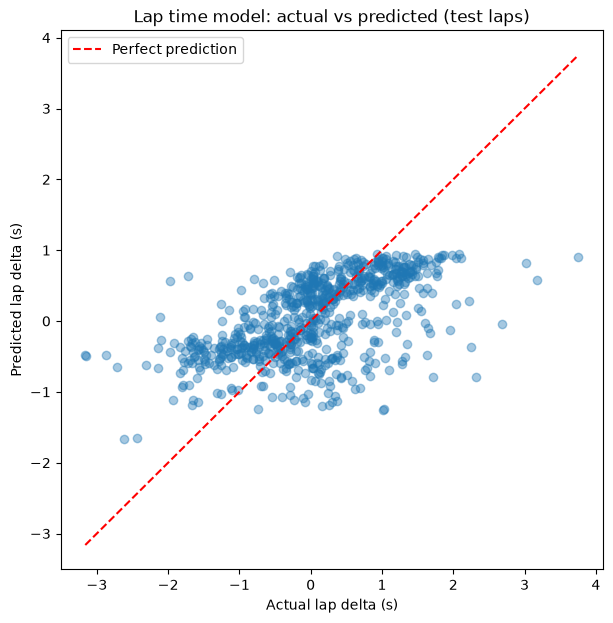

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual lap delta (s)")
plt.ylabel("Predicted lap delta (s)")
plt.title("Lap time model: actual vs predicted (test laps)")
plt.legend()
plt.show()

In [13]:
scenarios = pd.DataFrame({
    "TyreLife": [20, 20, 20],
    "LapNumber": [30, 30, 30],
    "TrackTemp": [35, 35, 35],
    "IsSoft": [1, 0, 0],
    "IsMedium": [0, 1, 0],
})
scenarios["TyreLife_Soft"] = scenarios["TyreLife"] * scenarios["IsSoft"]
scenarios["TyreLife_Medium"] = scenarios["TyreLife"] * scenarios["IsMedium"]

scenarios["Predicted delta (s)"] = lap_model.predict(scenarios[X.columns]).round(3)
scenarios.index = ["Soft", "Medium", "Hard"]
scenarios[["Predicted delta (s)"]]

,Predicted delta (s)
Soft,0.316
Medium,0.310
Hard,0.042


### Findings

- The model predicts lap time changes with an average error of **0.6 s** and explains about **34%** of variation (test R² = 0.338) on unseen laps.
- **Tyre age and fuel burn are the main drivers**: tyres add about 0.02–0.04 s per lap of age, while fuel burn removes about 0.03 s per lap.
- **Track temperature has almost no effect** (0.002 s per °C) once each driver's normal pace is accounted for.
- The model predicts general trends well but **cannot predict extreme laps** caused by traffic or mistakes.

### Limitations

- The what-if comparison shows Soft and Medium almost equal at 20 laps old. Very few laps exist on Softs that old, so the model is extrapolating. The per-compound results in section 7 are more reliable for Soft tyres.

## 9. Undercut vs overcut
When two cars are running close together, does it pay to pit first (undercut) or stay out longer (overcut)?

A "pit battle" is counted when two drivers are next to each other on track (within 3 s) and both make their first stop within 5 laps of each other. The attacker is whichever car was behind before the stops. The strategy succeeds if the attacker is ahead once both have pitted.

In [14]:
raw = df.copy()   # uncleaned data: we need the pit laps here
raw["LapEndTime"] = pd.to_timedelta(raw["Time_x"]).dt.total_seconds()
raw["TrackStatusNum"] = pd.to_numeric(raw["TrackStatus"], errors="coerce")

events = []
for race, r in raw.groupby("Race"):
    pos = r.pivot_table(index="LapNumber", columns="Driver", values="Position")
    end = r.pivot_table(index="LapNumber", columns="Driver", values="LapEndTime")
    status = r.pivot_table(index="LapNumber", columns="Driver", values="TrackStatusNum")
    first_stop = r[r["PitInTime"].notna()].groupby("Driver")["LapNumber"].min()

    for x, px in first_stop.items():                # x = driver who pitted first
        before = px - 1
        if before not in pos.index or pd.isna(pos.at[before, x]):
            continue
        for y, py in first_stop.items():            # y = rival who pitted 1–5 laps later
            if y == x or not (1 <= py - px <= 5):
                continue
            if pd.isna(pos.at[before, y]) or abs(pos.at[before, x] - pos.at[before, y]) != 1:
                continue                            # must be running next to each other
            gap = abs(end.at[before, x] - end.at[before, y])
            if pd.isna(gap) or gap > 3:
                continue                            # must be within 3 seconds
            after = py + 2                          # a lap after the rival's out-lap
            if after not in pos.index or pd.isna(pos.at[after, x]) or pd.isna(pos.at[after, y]):
                continue

            x_behind_before = pos.at[before, x] > pos.at[before, y]
            attacker, defender = (x, y) if x_behind_before else (y, x)
            events.append({
                "Race": race,
                "Attacker": attacker,
                "Defender": defender,
                "Strategy": "Undercut" if attacker == x else "Overcut",
                "Gap before (s)": round(gap, 2),
                "Success": pos.at[after, attacker] < pos.at[after, defender],
                "Green flag stops": status.at[px, x] == 1 and status.at[py, y] == 1,
            })

events = pd.DataFrame(events)
print(len(events), "pit battles found")
events

27 pit battles found


,Race,Attacker,Defender,Strategy,Gap before (s),Success,Green flag stops
0,Bahrain,BEA,ALB,Undercut,1.65,True,True
1,Bahrain,ALO,BEA,Overcut,2.62,False,True
2,Bahrain,DOO,TSU,Undercut,0.89,True,True
3,Bahrain,ANT,GAS,Overcut,0.59,False,True
4,Bahrain,LAW,ALO,Undercut,1.70,False,True
5,Bahrain,NOR,RUS,Undercut,0.98,False,True
6,Bahrain,OCO,DOO,Undercut,0.81,True,True
7,Bahrain,LEC,RUS,Overcut,2.48,False,True
8,Bahrain,ALB,SAI,Overcut,1.11,False,True
9,Bahrain,BOR,STR,Overcut,1.39,False,True


In [15]:
green = events[events["Green flag stops"]]   # stops under safety car are unfairly cheap
print(len(green), "battles with green-flag stops")

summary = green.groupby("Strategy")["Success"].agg(Battles="count", SuccessRate="mean")
summary["SuccessRate"] = (summary["SuccessRate"] * 100).round(1)
summary

26 battles with green-flag stops


,Battles,SuccessRate
Strategy,,
Overcut,11,9.1
Undercut,15,46.7


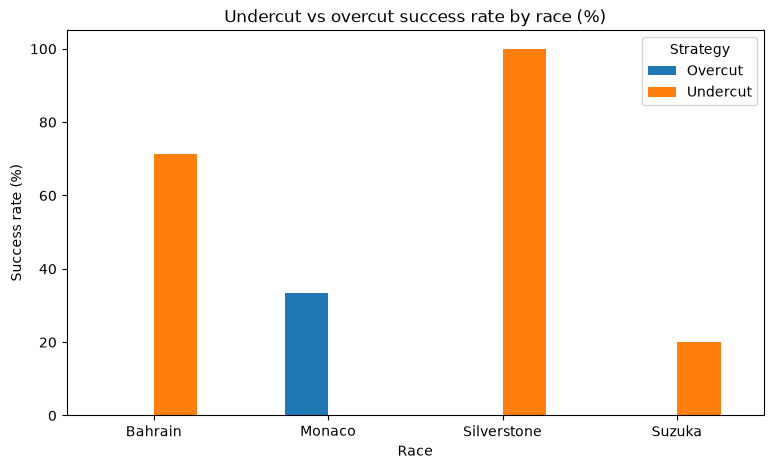

Battles          Successes         
Strategy    Overcut Undercut   Overcut Undercut
Race                                           
Bahrain           6        7         0        5
Monaco            3        2         1        0
Silverstone       0        1         0        1
Suzuka            2        5         0        1

In [16]:
by_race = green.groupby(["Race", "Strategy"])["Success"].mean().unstack() * 100
by_race.plot(kind="bar", figsize=(9, 5))
plt.title("Undercut vs overcut success rate by race (%)")
plt.ylabel("Success rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Strategy")
plt.show()

# Counts behind each bar (0% bars are invisible on the chart)
green.groupby(["Race", "Strategy"])["Success"].agg(Battles="count", Successes="sum").unstack(fill_value=0)

### Findings

- **The undercut worked far more often than the overcut**: 46.7% success (7 of 15) vs 9.1% (1 of 11).
- **Bahrain shows the strongest undercut effect** (5 of 7 successful, 0 of 6 overcuts). Bahrain also supplied most of the Soft tyre laps in section 7, the compound with by far the fastest wear, which fits the idea that fresh tyres give a bigger advantage when tyres wear quickly.
- **At Monaco, the undercut failed** (0 of 2), likely because overtaking is nearly impossible and track position matters more than tyre pace.
- **At Suzuka, the undercut rarely worked** (1 of 5).

### Limitations

- Only 26 battles across 5 races, so per-race results are based on very few examples (Silverstone has just 1).
- Success only checks positions after both stops. It doesn't account for on-track overtakes or mistakes that happened around the stops.
- No battles at Monza met the criteria (two cars within 3 s, both stopping within 5 laps of each other).
- Explanations for individual races (e.g. Monaco's track position) are likely reasons, not something this analysis tested directly.